In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# df=pd.read_csv(r"C:\Users\Alok Sahu\Downloads\spam.csv")
# df.sample(5)

df = pd.read_csv(
    r"C:\Users\Alok Sahu\Downloads\spam.csv",
    encoding="latin1"
)


In [3]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4981,ham,Slept? I thinkThis time ( &lt;#&gt; pm) is no...,NaN,NaN,NaN
422,ham,Siva is in hostel aha:-.,NaN,NaN,NaN
810,ham,S:)s.nervous &lt;#&gt; :),NaN,NaN,NaN
4267,ham,Hey so whats the plan this sat?,NaN,NaN,NaN
4343,ham,Hi:)did you asked to waheeda fathima about leave?,NaN,NaN,NaN


1:Data cleaning

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [5]:
df.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"],inplace=True)

In [6]:
df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [9]:
#renaming the cols
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
1923,ham,Hello. They are going to the village pub at 8 ...
1439,ham,In fact when do you leave? I think addie goes ...
4364,ham,Ujhhhhhhh computer shipped out with address to...
88,ham,I'm really not up to it still tonight babe
1357,ham,Good afternoon loverboy ! How goes you day ? A...


In [10]:
from sklearn.preprocessing import LabelEncoder


In [11]:
encoder=LabelEncoder()

In [12]:
df["target"]=encoder.fit_transform(df["target"])

In [13]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [14]:
#miss vlue
df.isnull().sum()

target    0
text      0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(403)

In [16]:
df=df.drop_duplicates(keep="first")

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
# EDA

In [19]:
df["target"].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

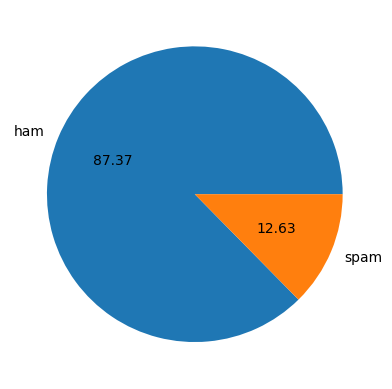

In [20]:
plt.pie(df["target"].value_counts(),labels=["ham","spam"],autopct="%0.2f")
plt.show()

In [21]:
#data is imbalanced

In [22]:
import nltk

In [23]:
df["num_characters"]= df["text"].apply(len)


C:\Users\Alok Sahu\AppData\Local\Temp\ipykernel_22852\2480688478.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["num_characters"]= df["text"].apply(len)


In [24]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [25]:
df["num_words"]=df["text"].apply(lambda x:len(nltk.word_tokenize(x)))

C:\Users\Alok Sahu\AppData\Local\Temp\ipykernel_22852\1558380898.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["num_words"]=df["text"].apply(lambda x:len(nltk.word_tokenize(x)))


In [26]:
df["num_sentences"]=df["text"].apply(lambda x:len(nltk.sent_tokenize(x)))

C:\Users\Alok Sahu\AppData\Local\Temp\ipykernel_22852\4263227907.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["num_sentences"]=df["text"].apply(lambda x:len(nltk.sent_tokenize(x)))


In [27]:
df[["num_words","num_sentences","num_characters"]].describe()

,num_words,num_sentences,num_characters
count,5169.000000,5169.000000,5169.000000
mean,18.455794,1.965564,78.977945
std,13.324758,1.448541,58.236293
min,1.000000,1.000000,2.000000
25%,9.000000,1.000000,36.000000
50%,15.000000,1.000000,60.000000
75%,26.000000,2.000000,117.000000
max,220.000000,38.000000,910.000000


In [28]:
df[df["target"]==0][["num_words","num_sentences","num_characters"]].describe()
#ham 

,num_words,num_sentences,num_characters
count,4516.000000,4516.000000,4516.000000
mean,17.123782,1.820195,70.459256
std,13.493970,1.383657,56.358207
min,1.000000,1.000000,2.000000
25%,8.000000,1.000000,34.000000
50%,13.000000,1.000000,52.000000
75%,22.000000,2.000000,90.000000
max,220.000000,38.000000,910.000000


In [29]:
df[df["target"]==1][["num_words","num_sentences","num_characters"]].describe()
#spam

,num_words,num_sentences,num_characters
count,653.000000,653.000000,653.000000
mean,27.667688,2.970904,137.891271
std,7.008418,1.488425,30.137753
min,2.000000,1.000000,13.000000
25%,25.000000,2.000000,132.000000
50%,29.000000,3.000000,149.000000
75%,32.000000,4.000000,157.000000
max,46.000000,9.000000,224.000000


<Axes: xlabel='num_characters', ylabel='Count'>

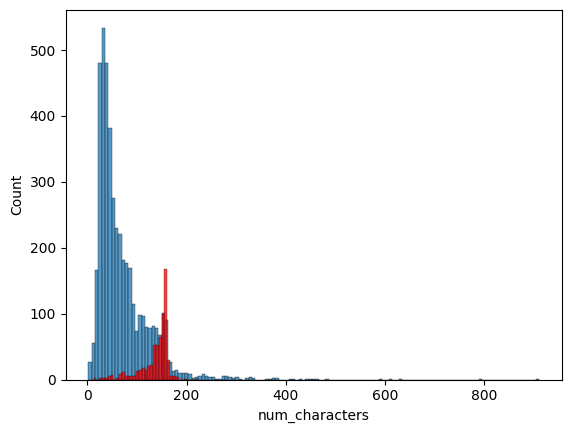

In [31]:
sns.histplot(df[df["target"]==0]["num_characters"])
sns.histplot(df[df["target"]==1]["num_characters"],color="red")

<Axes: xlabel='num_words', ylabel='Count'>

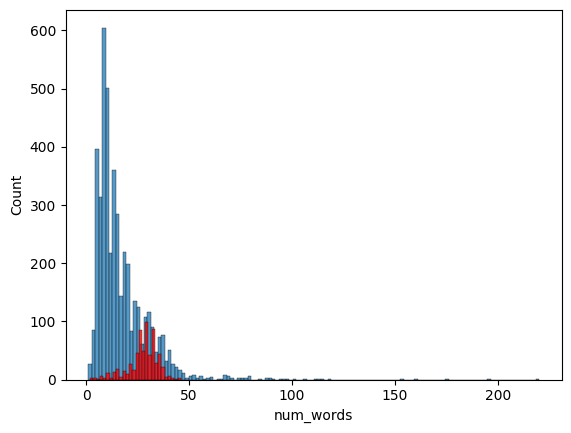

In [32]:
sns.histplot(df[df["target"]==0]["num_words"])
sns.histplot(df[df["target"]==1]["num_words"],color="red")

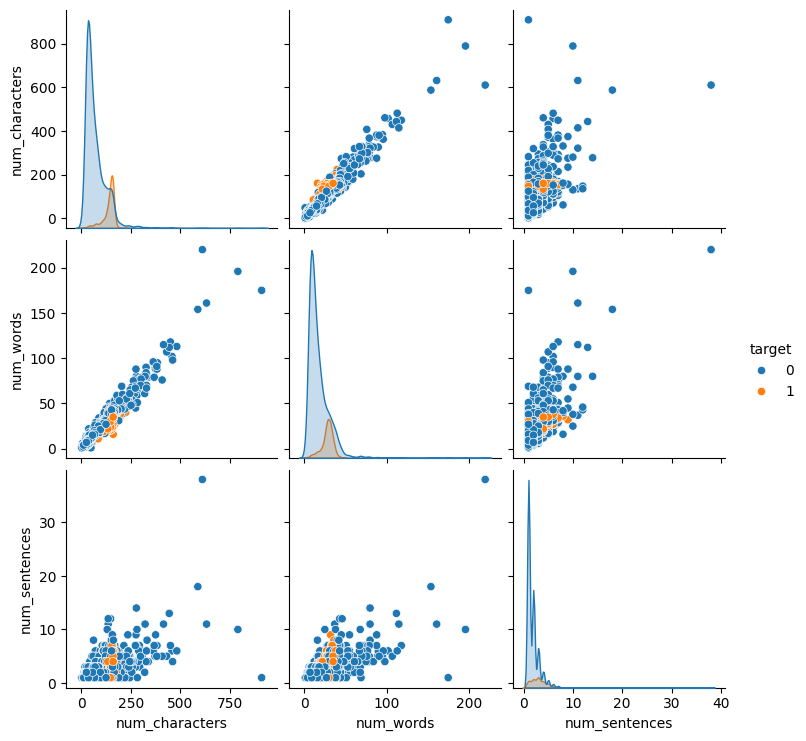

In [33]:
sns.pairplot(df,hue="target")
plt.show()

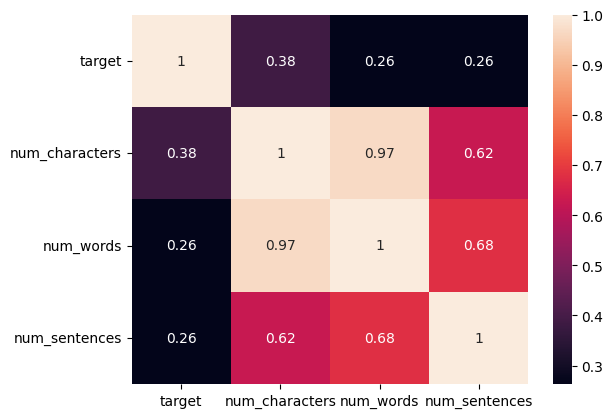

In [34]:
# sns.heatmap(df.corr(),annot=True)
# # plt.show()
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.show()


Data preprocessing

In [35]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\Alok
[nltk_data]     Sahu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [42]:
def transform_text(text):
    text=text.lower()
    text=nltk.word_tokenize(text)

    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)
    text=y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words("english") and i not in string.punctuation:
            y.append(i)

    text=y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    

    return y
            
    
    

In [146]:
transform_text("are you alok sahu,LOOking,gooding ....?")

['alok', 'sahu', 'look', 'good']

In [45]:
import string
import nltk

nltk.download('stopwords')
nltk.download('punkt')


# nltk.data.path.append("C:/Users/Alok Sahu/nltk_data")


[nltk_data] Downloading package stopwords to C:\Users\Alok
[nltk_data]     Sahu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Alok
[nltk_data]     Sahu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [47]:
import string


In [48]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()
ps.stem("looking")

'look'

In [49]:
df["text"].apply(transform_text)

0       [go, jurong, point, crazi, avail, bugi, n, gre...
1                            [ok, lar, joke, wif, u, oni]
2       [free, entri, 2, wkli, comp, win, fa, cup, fin...
3           [u, dun, say, earli, hor, u, c, alreadi, say]
4            [nah, think, goe, usf, live, around, though]
                              ...                        
5567    [2nd, time, tri, 2, contact, u, pound, prize, ...
5568                          [b, go, esplanad, fr, home]
5569                                [piti, mood, suggest]
5570    [guy, bitch, act, like, interest, buy, someth,...
5571                                   [rofl, true, name]
Name: text, Length: 5169, dtype: object

In [51]:
df["transform_text"]=df["text"].apply(transform_text)

C:\Users\Alok Sahu\AppData\Local\Temp\ipykernel_22852\733104182.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["transform_text"]=df["text"].apply(transform_text)


In [53]:
df.head()

,target,text,num_characters,num_words,num_sentences,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,"[go, jurong, point, crazi, avail, bugi, n, gre..."
1,0,Ok lar... Joking wif u oni...,29,8,2,"[ok, lar, joke, wif, u, oni]"
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,"[free, entri, 2, wkli, comp, win, fa, cup, fin..."
3,0,U dun say so early hor... U c already then say...,49,13,1,"[u, dun, say, earli, hor, u, c, alreadi, say]"
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,"[nah, think, goe, usf, live, around, though]"


In [82]:
from wordcloud import WordCloud
wc=WordCloud(width=500,height=500,min_font_size=10,background_color="white")



In [83]:
spam_wcc=wc.generate(df[df["target"]==1]["transform_text"].str.cat(sep=" "))
# df["transform_text"] = df["transform_text"].astype(str)


In [ ]:
# df["transform_text"] = df["transform_text"].astype(str)


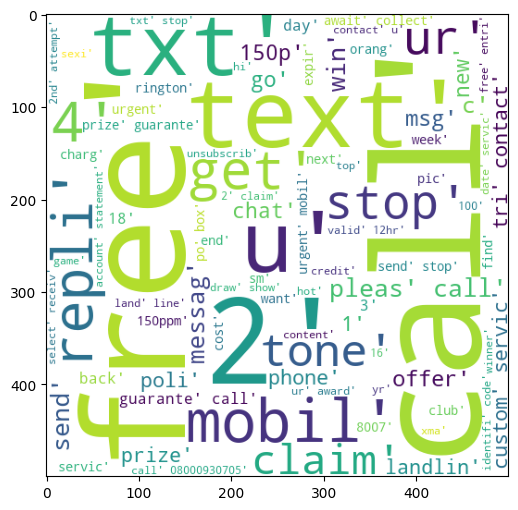

In [84]:
plt.figure(figsize=(12,6))
plt.imshow(spam_wcc)

In [85]:
ham_wcc=wc.generate(df[df["target"]==0]["transform_text"].str.cat(sep=" "))

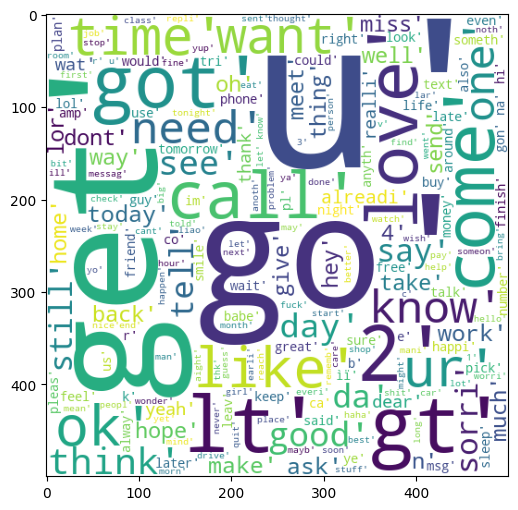

In [86]:
plt.figure(figsize=(12,6))
plt.imshow(ham_wcc)

In [87]:
df.head()

,target,text,num_characters,num_words,num_sentences,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,"['go', 'jurong', 'point', 'crazi', 'avail', 'b..."
1,0,Ok lar... Joking wif u oni...,29,8,2,"['ok', 'lar', 'joke', 'wif', 'u', 'oni']"
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,"['free', 'entri', '2', 'wkli', 'comp', 'win', ..."
3,0,U dun say so early hor... U c already then say...,49,13,1,"['u', 'dun', 'say', 'earli', 'hor', 'u', 'c', ..."
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,"['nah', 'think', 'goe', 'usf', 'live', 'around..."


In [88]:
spam_corpus=[]
for msg in df[df["target"]==0]["transform_text"].tolist():
    for word in msg.split():
        spam_corpus.append(word)
    

In [89]:
len(spam_corpus)

35413

In [157]:
# from collections import counter
from collections import Counter
 
# sns.barplot(pd.DataFrame(Counter(spam_corpus).most_common(30))[0],pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
# plt.xticks(rotation="vertical")

In [80]:
spam_df = pd.DataFrame(Counter(spam_corpus).most_common(30),columns=["word", "count"])


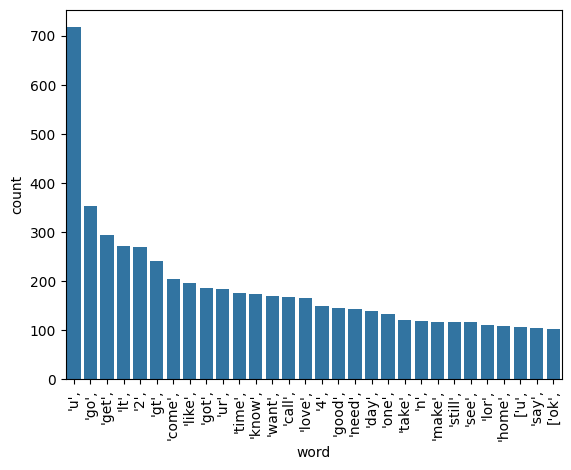

In [92]:
sns.barplot(data=spam_df, x="word", y="count")
plt.xticks(rotation=90)
plt.show()


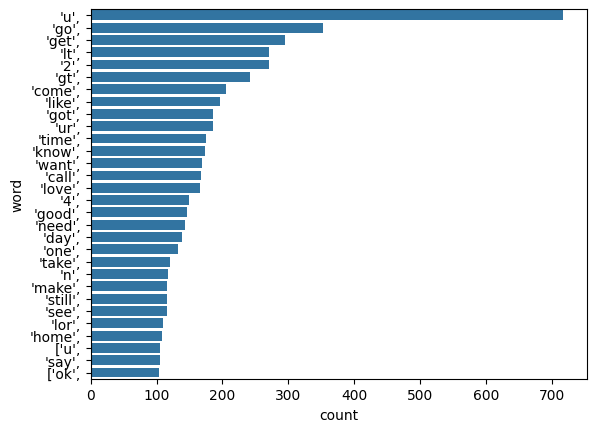

In [76]:
sns.barplot(data=spam_df, y="word", x="count")
plt.show()


In [199]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
# cv=CountVectorizer()
tfidf=TfidfVectorizer(max_features=3000)

In [200]:
# x=cv.fit_transform(df["transform_text"]).toarray()
x=tfidf.fit_transform(df["transform_text"]).toarray()

In [201]:
x.shape

(5169, 3000)

In [202]:
y=df["target"].values

In [203]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [204]:
from sklearn.model_selection import train_test_split

In [205]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=2,test_size=0.2)

In [206]:
# from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.naive_bayes import MultinomialNB
# from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [207]:
# gnb=GaussianNB()
mnb=MultinomialNB()
# bnb=BernoulliNB()

In [208]:
# gnb.fit(x_train,y_train)
# # gnb.score(x_test,y_test)*100
# y_pred1=gnb.predict(x_test)
# print(accuracy_score(y_test,y_pred1))
# print(confusion_matrix(y_test,y_pred1))
# print(precision_score(y_test,y_pred1))

In [209]:
mnb.fit(x_train,y_train)
# gnb.score(x_test,y_test)*100
# y_pred2=mnb.predict(x_test)
# print(accuracy_score(y_test,y_pred2))
# print(confusion_matrix(y_test,y_pred2))
# print(precision_score(y_test,y_pred2))

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [210]:
# bnb.fit(x_train,y_train)
# # gnb.score(x_test,y_test)*100
# y_pred3=bnb.predict(x_test)
# print(accuracy_score(y_test,y_pred3))
# print(confusion_matrix(y_test,y_pred3))
# print(precision_score(y_test,y_pred3))

In [211]:
import pickle
# pickle.dump(tfidf,open("vectorizer.pkl","wb"))
# pickle.dump(tfidf,open("model.pkl","wb"))
pickle.dump(tfidf, open("vectorizer.pkl","wb"))
pickle.dump(mnb, open("model.pkl","wb"))